## **Perbandingan Kinerja Algoritma Random Forest dan Logistic Regression dalam Menentukan Kualitas Anggur Merah**

# Dibuat Oleh: **Jessica Aurelia Purwanto**

In [ ]:
#Import library yang digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, accuracy_score
from sklearn.preprocessing import LabelBinarizer

**Mengimport Data**

In [ ]:
#input data
link = "https://raw.githubusercontent.com/jessicaureliap/Tugas-Akhir_PDS/refs/heads/main/winequality-red.csv"
data = pd.read_csv(link)
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


**Memahami dan Mengeksplorasi Data**

In [ ]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# Mengecek missing value
data.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
#Mengecek apakah terdapat duplikat data
data.duplicated().any()

np.True_

In [ ]:
#Memeriksa jumlah baris yang terduplikat
jumlah_duplikat = data.duplicated().sum()
print(f"Total baris duplikat yang ditemukan: {jumlah_duplikat}")

Total baris duplikat yang ditemukan: 240


In [ ]:
#Menghapus baris yang terduplikat
data_clean = data.drop_duplicates(keep='first', inplace=False)

# Memeriksa ukuran dataset setelah penghapusan
print(f"Ukuran dataset setelah penghapusan: {data_clean.shape}")

Ukuran dataset setelah penghapusan: (1359, 12)


In [ ]:
#Menampilkan data bersih kolom kualitas
data_clean['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [ ]:
#ringkasan statistik
data_clean.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
# Mencari data unik
data_clean.apply(lambda x: len(x.unique()))

,0
fixed acidity,96
volatile acidity,143
citric acid,80
residual sugar,91
chlorides,153
free sulfur dioxide,60
total sulfur dioxide,144
density,436
pH,89
sulphates,96


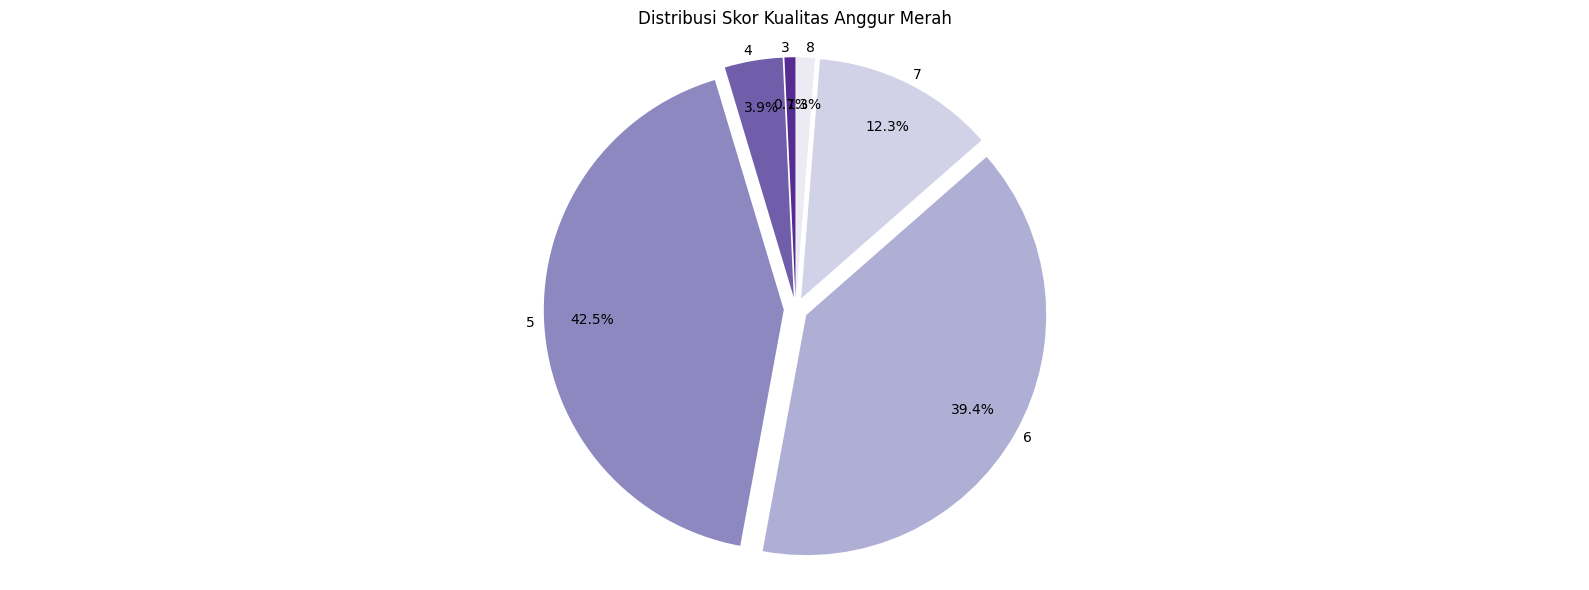

In [ ]:
# Distribusi Target
# Hitung Frekuensi
quality_counts = data_clean['quality'].value_counts().sort_index()

# Tentukan Pengaturan Visual
explode = [0.05] * len(quality_counts)
colors = sns.color_palette('Purples_r', len(quality_counts))

#  Buat Pie Chart
plt.figure(figsize=(16, 6))

plt.pie(
    quality_counts,
    labels=quality_counts.index,
    autopct='%1.1f%%', # Format sederhana: menampilkan persentase dengan satu desimal
    startangle=90,
    colors=colors,
    explode=explode,
    pctdistance=0.8,
    labeldistance=1.04
)

# Tambahkan Judul
plt.title('Distribusi Skor Kualitas Anggur Merah', fontsize=12)

# Pastikan berbentuk lingkaran (aspect ratio yang sama)
plt.axis('equal')

# General layout improvements

plt.tight_layout()

plt.show()


/tmp/ipython-input-1758526576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


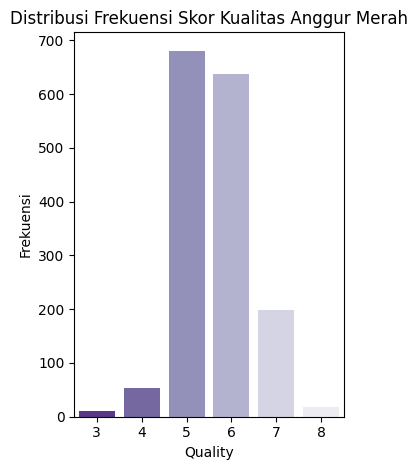

In [ ]:
# Distribusi Target
# Hitung Frekuensi
quality_counts = data_clean['quality'].value_counts().sort_index()

plt.subplot(1, 2, 2)
sns.countplot(
    data=data,
    x='quality',
    palette='Purples_r',
)

plt.title('Distribusi Frekuensi Skor Kualitas Anggur Merah', fontsize=12)
plt.xlabel('Quality', fontsize=10)
plt.ylabel('Frekuensi', fontsize=10)

# General layout improvements

plt.tight_layout()
plt.show()

In [ ]:
#kolom numerik
numerical_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                  'chlorides','free sulfur dioxide','total sulfur dioxide', 'density',
                  'pH','sulphates','alcohol']


/tmp/ipython-input-2511109601.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data_clean[column], kde=True, color='purple', ax=ax, palette='RdGy')
/tmp/ipython-input-2511109601.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data_clean[column], kde=True, color='purple', ax=ax, palette='RdGy')
/tmp/ipython-input-2511109601.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data_clean[column], kde=True, color='purple', ax=ax, palette='RdGy')
/tmp/ipython-input-2511109601.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data_clean[column], kde=True, color='purple', ax=ax, palette='RdGy')
/tmp/ipython-input-2511109601.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data_clean[column], kde=True, color='purple', ax=ax, palette='RdGy')
/tmp/ipython-in

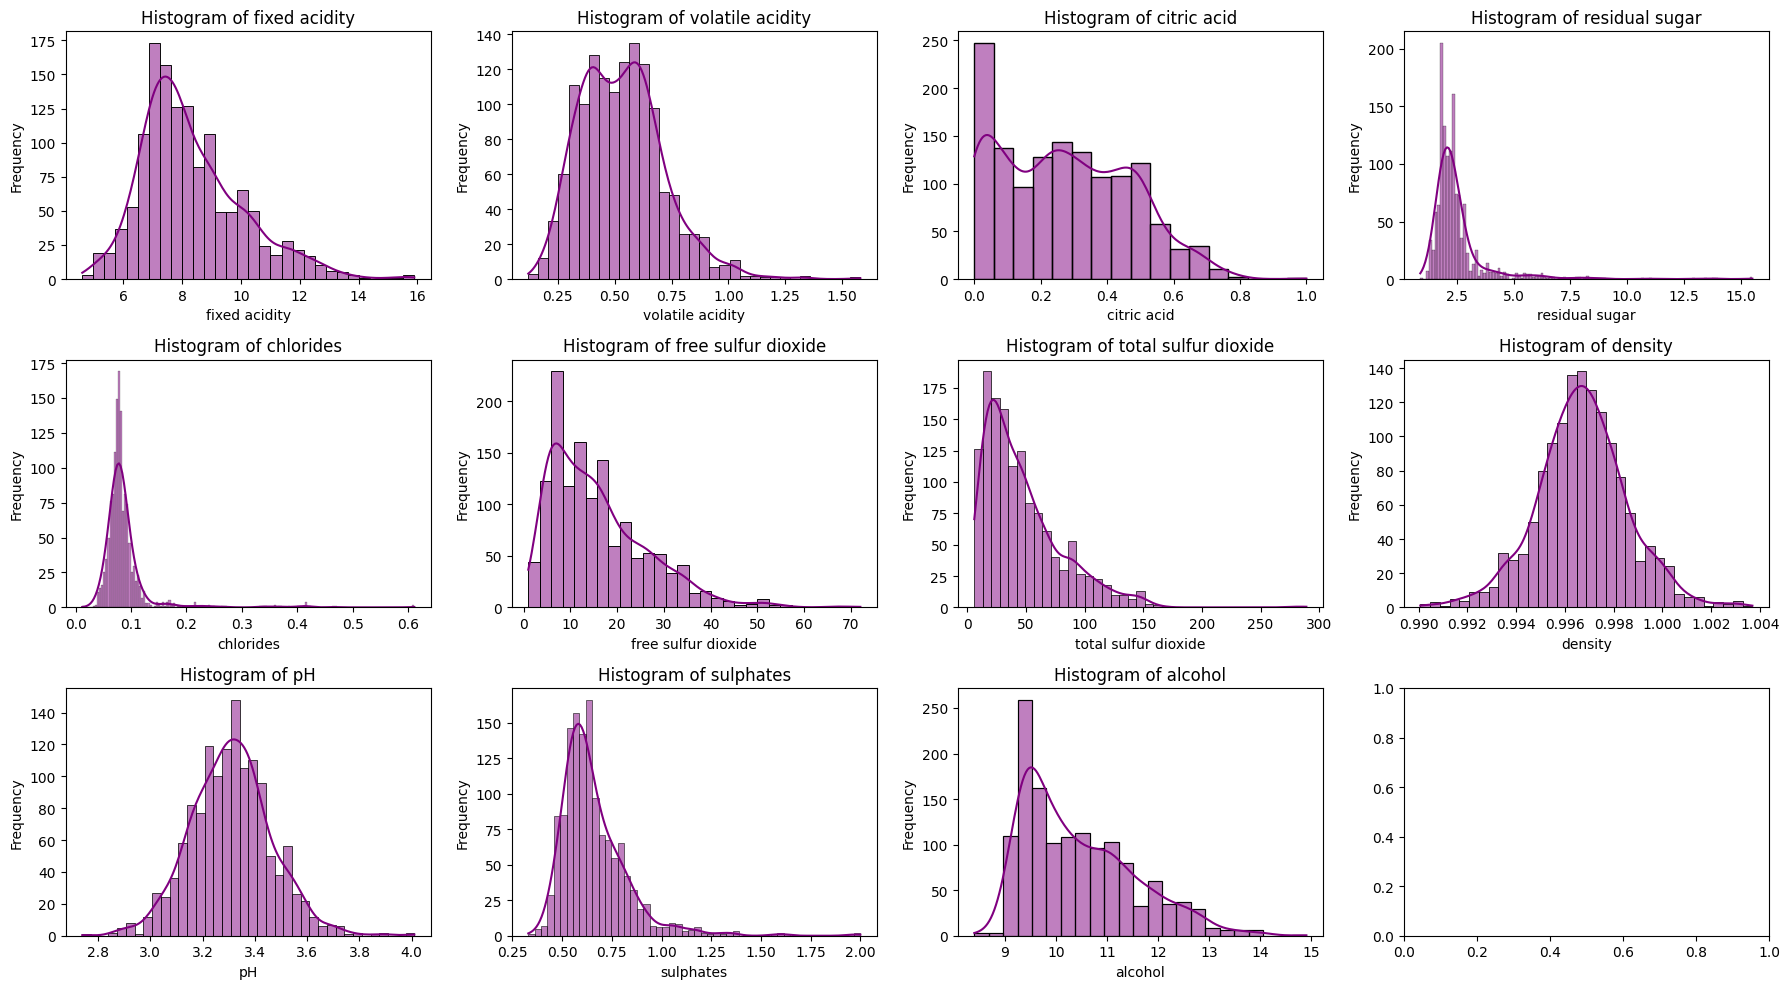

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))

for i, column in enumerate(numerical_cols):

    ax = axes[i // 4, i % 4]

    sns.histplot(data_clean[column], kde=True, color='purple', ax=ax, palette='RdGy')

    ax.set_title(f'Histogram of {column}')

    ax.set_xlabel(column)

    ax.set_ylabel('Frequency')

plt.tight_layout()

plt.show()

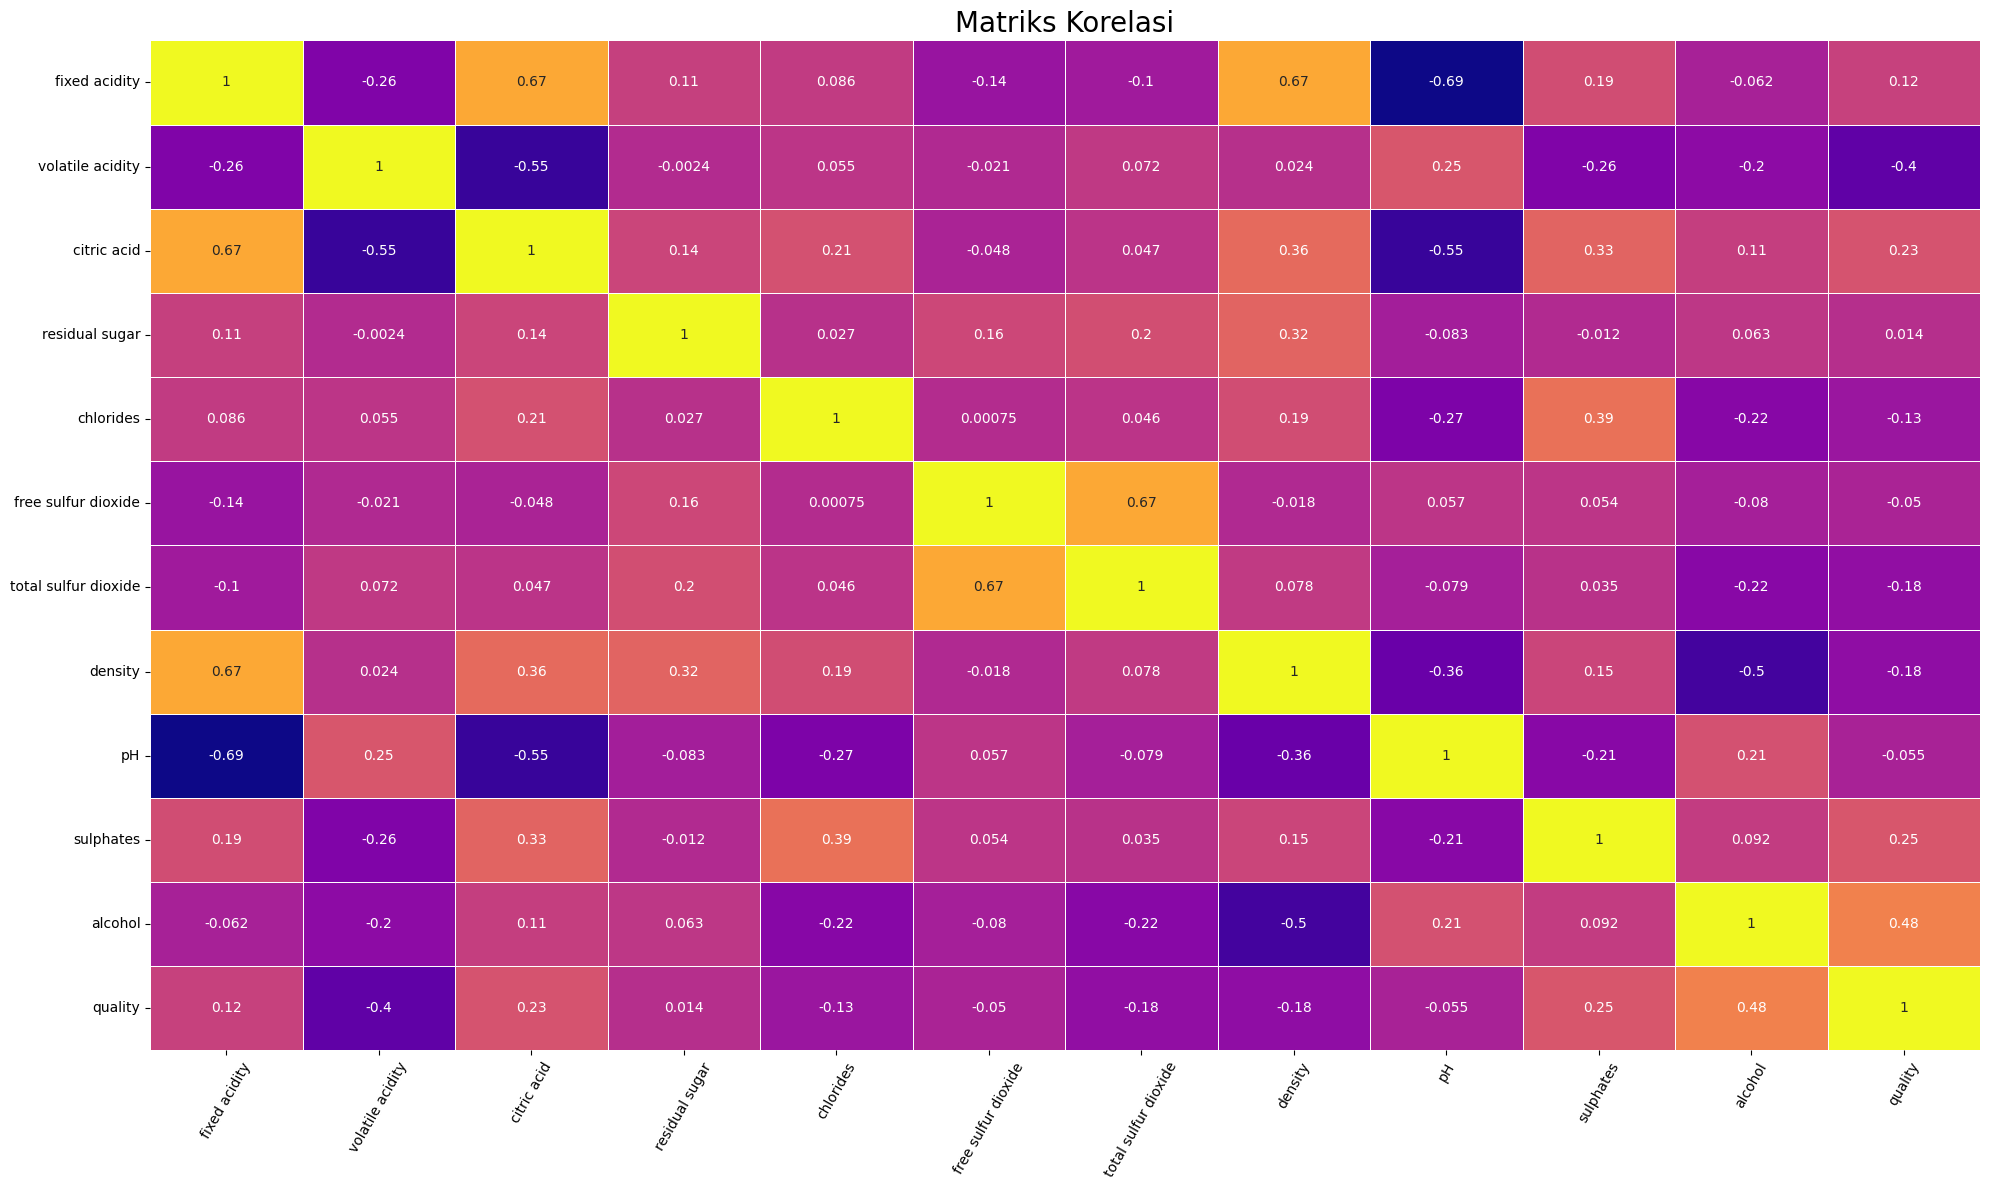

In [ ]:
#Matriks Korelasi
plt.figure(figsize=(20, 12))

sns.heatmap(data_clean.corr(numeric_only=True), cmap="plasma", annot=True, linewidths=.6 , cbar = False)

plt.xticks(rotation=60, size=10)

plt.yticks(size=10)

plt.title('Matriks Korelasi', size=20)

plt.tight_layout()

plt.show()

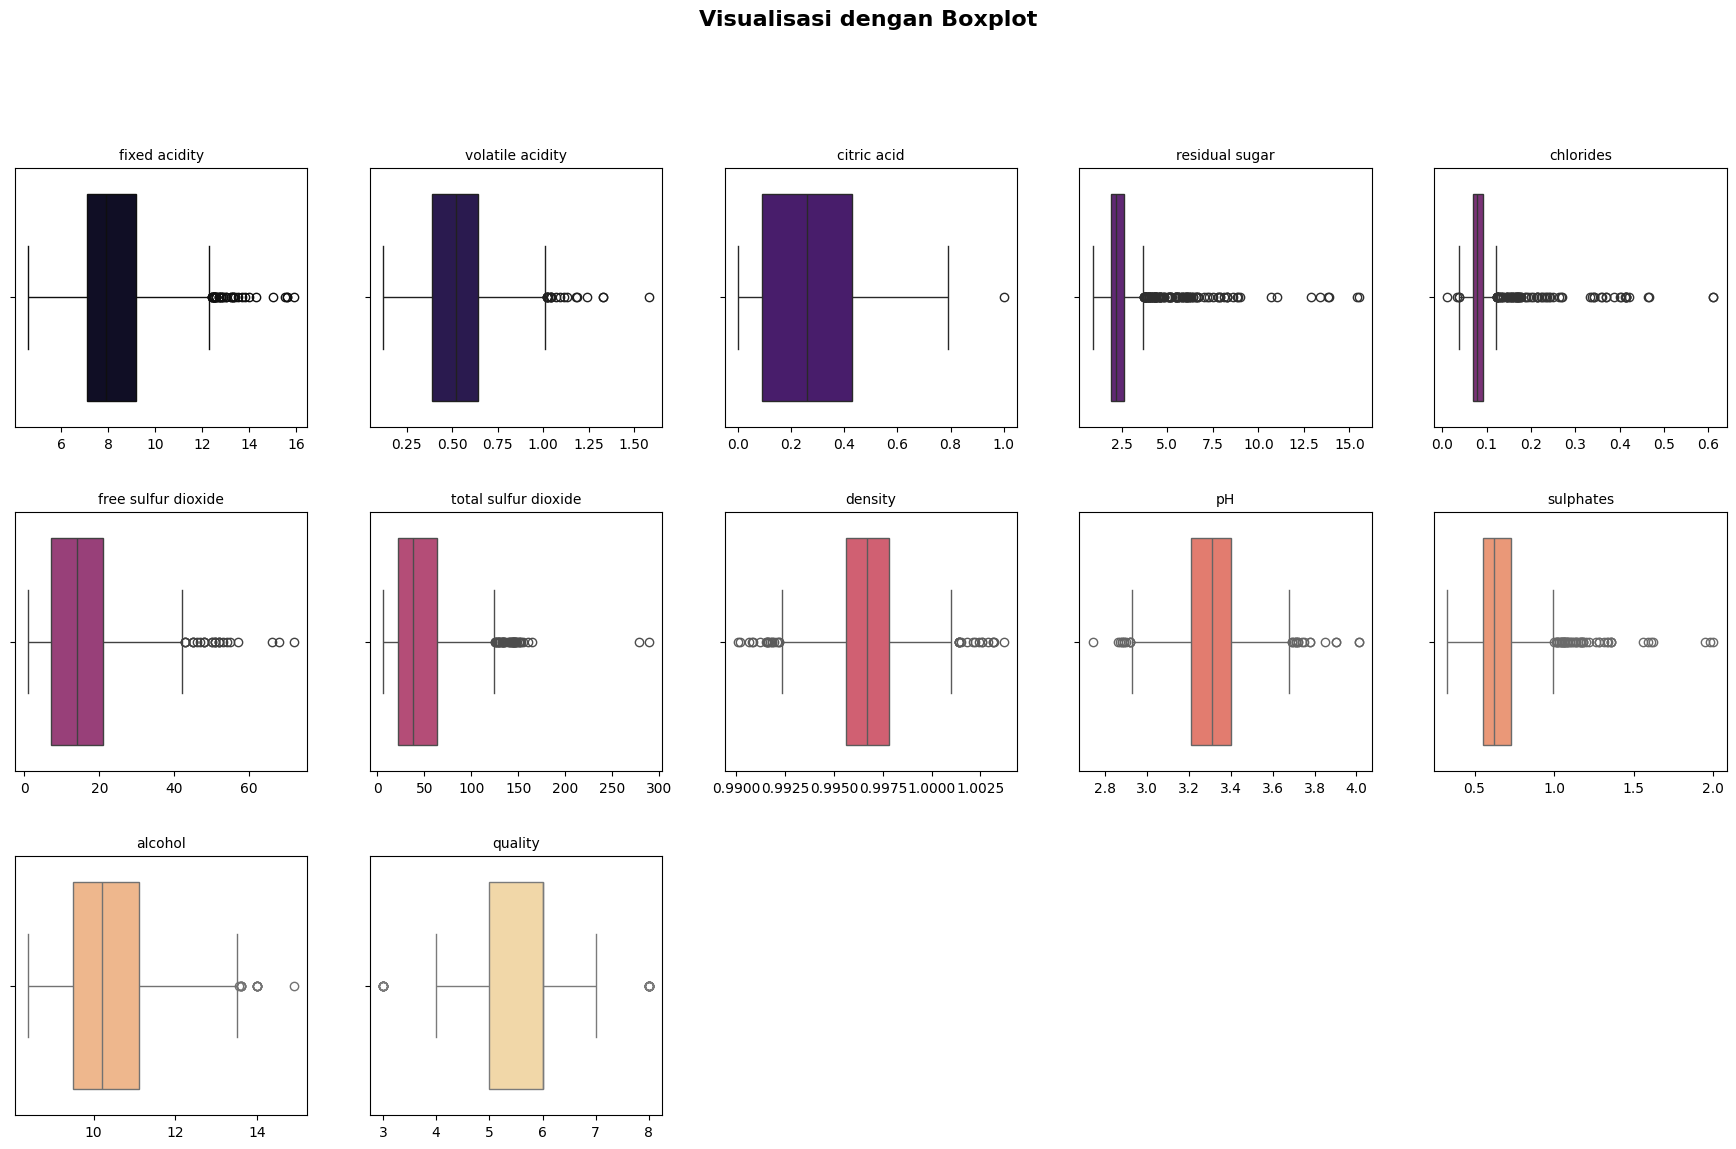

In [ ]:
# Boxplot untuk mengecek outlier (dengan data awal)
kolom_numerik = data_clean.describe().columns[:12]
# Buat palet
palette = sns.color_palette("magma", len(kolom_numerik))
plt.figure(figsize=(18, 18))

# Loop melalui kolom dan indeks
for i in enumerate(kolom_numerik):
    # i[0] adalah indeks (0, 1, 2...), i[1] adalah nama kolom
    plt.subplot(5, 5, i[0] + 1)
    sns.boxplot(
        x=data_clean[i[1]],
        color=palette[i[0]]
    )
    plt.title(i[1], fontsize=10)
    plt.xlabel('')

plt.suptitle("Visualisasi dengan Boxplot", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(pad=3.0) # Menambahkan padding agar lebih rapi
plt.show()

**Pre-Processsing Data**

In [ ]:
#Menyederhanakan label target menjadi 2 label yaitu Bad Wine(0) & Good Wine(1)
df=data_clean.copy()
df['quality'] = np.where(df['quality'] >= 6.5, 1, 0)

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


In [ ]:
#Membagi data jadi fitur(x) dan target(y)
X = df.drop('quality', axis = 1).values
y = df['quality']

In [ ]:
#Membagi menjadi data train dan test (80:20)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1,stratify=y)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1087, 11)
y_train shape: (1087,)
X_test shape: (272, 11)
y_test shape: (272,)


In [ ]:
#Menstandarisasi data dengan standar scaler
sc= StandardScaler()

# Hitung rata-rata & standar deviasi dari X_train, lalu mwntransformasikan keduanya
X_train_scl = sc.fit_transform(X_train)
X_test_scl = sc.transform(X_test)
y_train_scl = y_train.ravel()
y_test_scl = y_test.ravel()

/tmp/ipython-input-3814467285.py:7: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train_scl = y_train.ravel()
/tmp/ipython-input-3814467285.py:8: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test_scl = y_test.ravel()


**Pemodelan Dengan Random Forest**

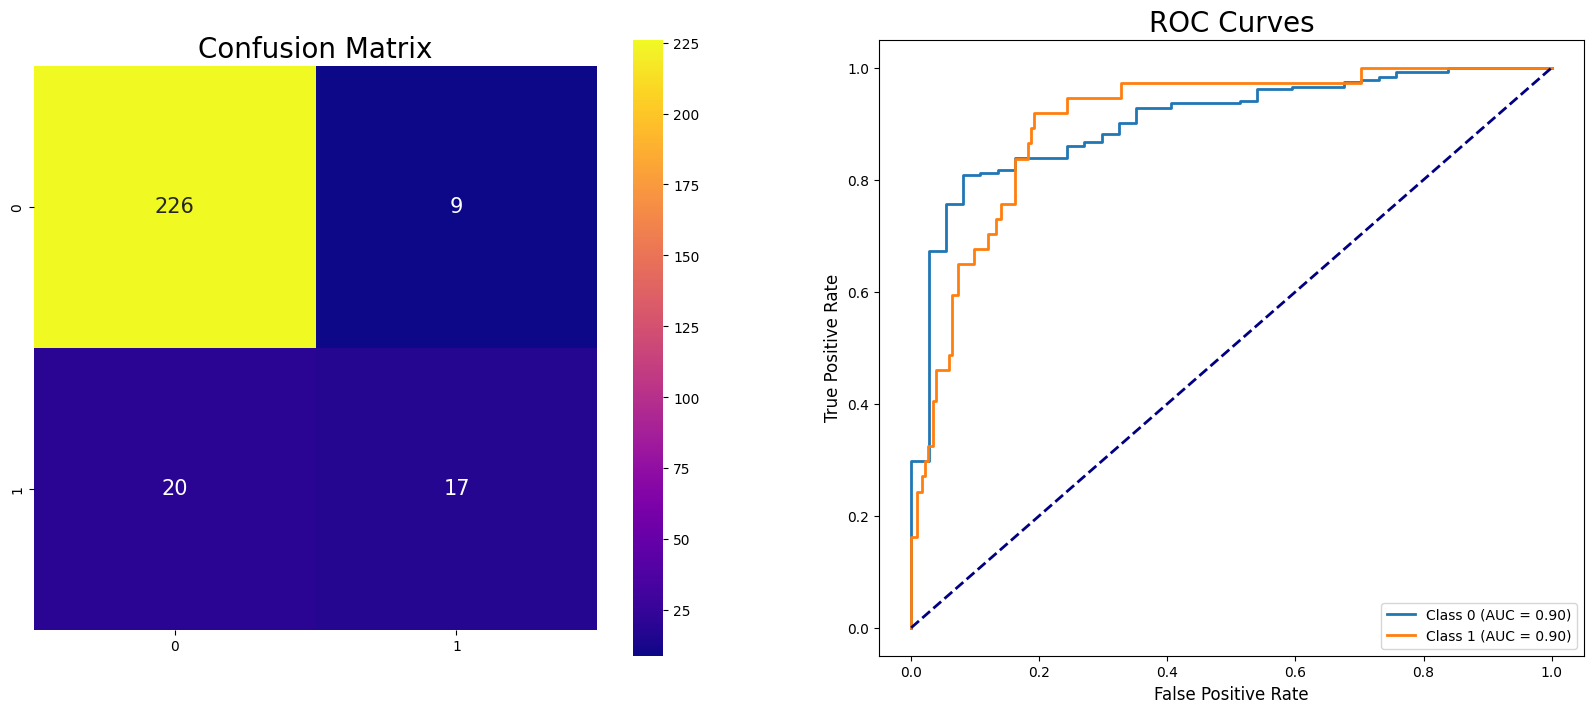

In [ ]:
#Confussion Matrix dan Kurva ROC
# 1. Pastikan ambil probabilitas terlebih dahulu
y_pred_prob_m = clf.predict_proba(X_test_scl)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot Confusion Matrix ---
sns.heatmap(confusion_matrix(y_test_scl, y_pred), annot=True,
            cmap='plasma', annot_kws={'size': 15},
            square=True, fmt='.0f', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=20)

# --- Plot ROC Curve ---
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_scl)

if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))

for i in range(y_test_bin.shape[1]):
    # GANTI y_pred[:, i] menjadi y_pred_prob[:, i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob_m[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})', lw=2)

# Tambahkan garis diagonal putus-putus sebagai referensi
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves', fontsize=20)
axes[1].legend(loc="lower right")
plt.show()

In [ ]:
#Precission, Recall, F1-Score
print('-'*60, '\n')
print("Accuracy :" ,metrics.accuracy_score(y_test_scl,y_pred))
print(classification_report(y_test_scl,y_pred, zero_division=1))
print('-'*60, '\n')

------------------------------------------------------------ 

Accuracy : 0.8933823529411765
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       235
           1       0.65      0.46      0.54        37

    accuracy                           0.89       272
   macro avg       0.79      0.71      0.74       272
weighted avg       0.88      0.89      0.89       272

------------------------------------------------------------ 



In [ ]:
#Visualisasi Random Forest
feature=df.drop('quality', axis = 1)
feature_names= feature.columns.tolist()
target_nmaes=['0','1']
fig = plt.figure(figsize=(200,200))
plot = tree.plot_tree(clf.estimators_[5],
                     feature_names=feature_names,
                     class_names=target_nmaes,
                     filled = True)

**Regresi Logistik**

In [ ]:
#Pemodelan Regresi Logistik
log_reg1 = LogisticRegression( class_weight='balanced',C=1.2, fit_intercept=True, max_iter=50, penalty = 'l1', solver='saga')

In [ ]:
# Train the model and make predictions
log_reg1.fit(X_train_scl, y_train_scl)
# Prediksi label dan probabilitas
y_pred_log = log_reg1.predict(X_test_scl)
y_pred_prob = log_reg1.predict_proba(X_test_scl)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


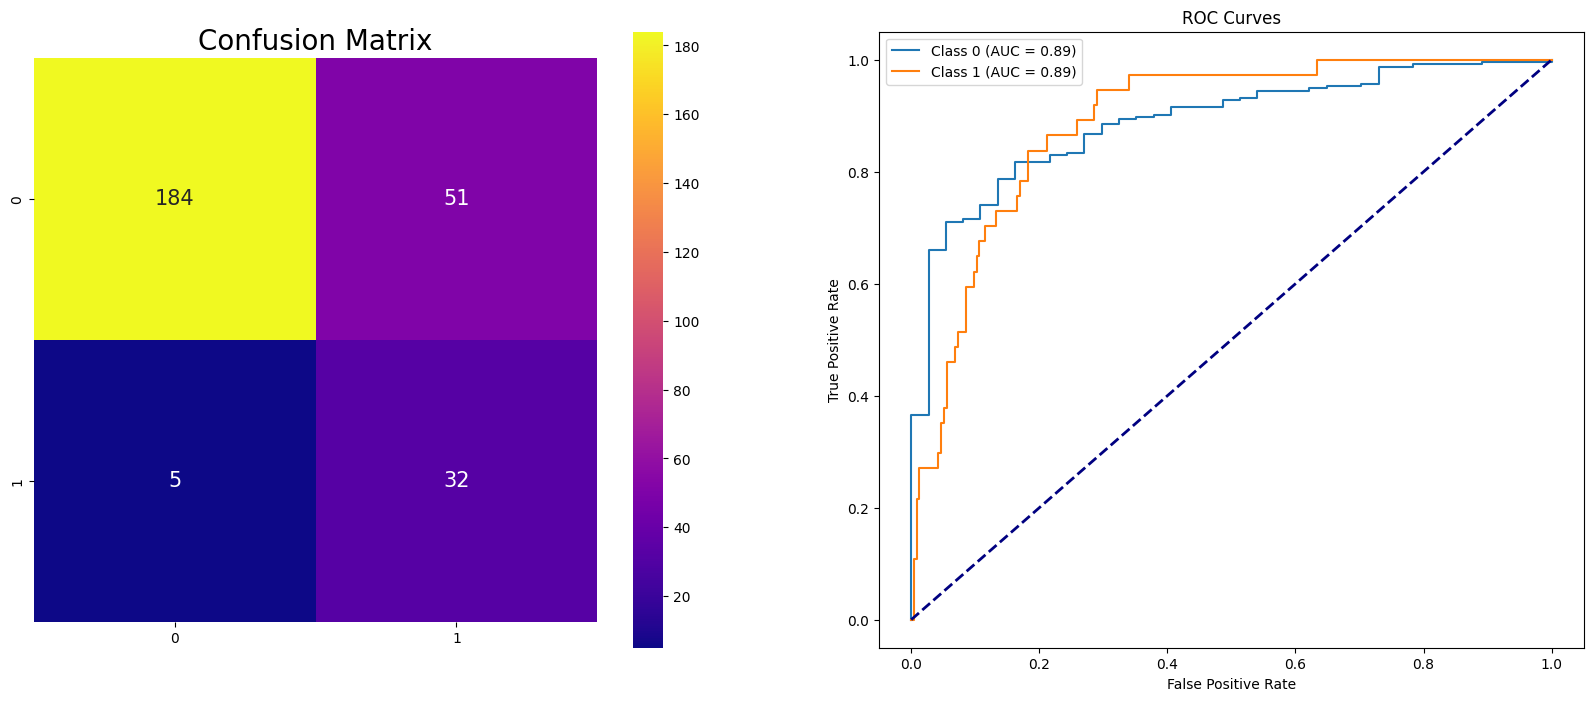

In [ ]:
#Confussion Matrix dan Kurva ROC
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot Confusion Matrix ---
sns.heatmap(confusion_matrix(y_test_scl, y_pred_log), annot=True,
            cmap='plasma', annot_kws={'size': 15},
            square=True, fmt='.0f', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=20)

# --- Plot ROC Curve ---
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_scl)

# Jika biner (2 kelas), pastikan bentuk array benar
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Tambahkan garis diagonal putus-putus sebagai referensi
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()
plt.show()

In [ ]:
#Precission, Recall, F1-Score
print('-'*60, '\n')
print("Accuracy :" ,metrics.accuracy_score(y_test_scl,y_pred_log))
print(classification_report(y_test_scl,y_pred_log, zero_division=1))
print('-'*60, '\n')

------------------------------------------------------------ 

Accuracy : 0.7941176470588235
              precision    recall  f1-score   support

           0       0.97      0.78      0.87       235
           1       0.39      0.86      0.53        37

    accuracy                           0.79       272
   macro avg       0.68      0.82      0.70       272
weighted avg       0.89      0.79      0.82       272

------------------------------------------------------------ 

